# Acompanhamento 1: Análise Exploratória e Limpeza de Dados
Competição de Machine Learning - Previsão de Preços de Imóveis


**Equipe:**
* Kalil Smith Pinto Palheta - 2223857
* Gabriel Abreu Cunha De Alencar - 2315097
* Igor Gomes Ximenes - 2217665

## 1. Importação de Bibliotecas e Carregamento dos Dados

In [76]:
import pandas as pd 
import joblib
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
# So usado depois no codigo 
from sklearn.model_selection import train_test_split, cross_validate, KFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_log_error
from xgboost import XGBRegressor

# Apenas configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# Carregamento no base 
df_treino = pd.read_csv('treino.csv')

# Visão inicial do dataset
display(df_treino.head())
print(f"O dataset de treino {df_treino.shape[0]} linhas e {df_treino.shape[1]} colunas.")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


O dataset de treino 1168 linhas e 81 colunas.


## <h3>2. Análise Exploratória da Variável Alvo (`SalePrice`)</h3>
Antes de analisar as variáveis explicativas, precisamos entender o comportamento dos preços das casas.

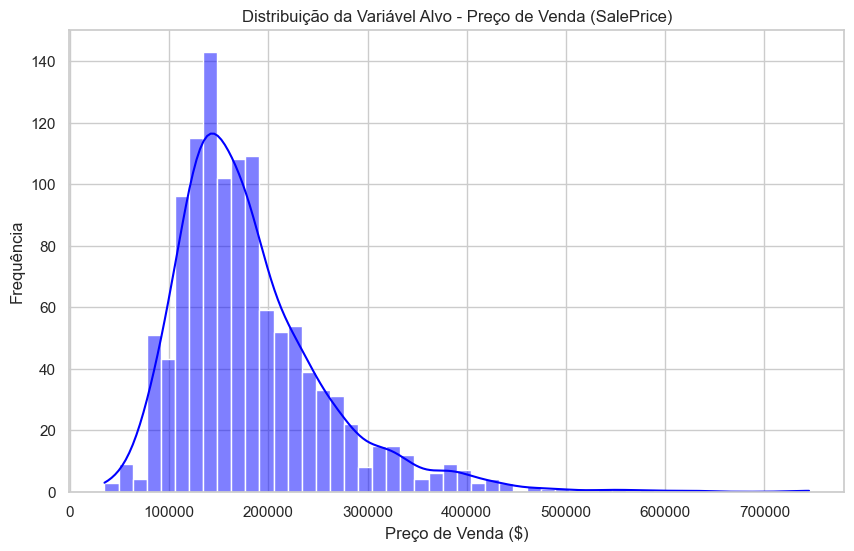

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64


In [67]:
plt.figure(figsize=(10, 6))
sns.histplot(df_treino['SalePrice'], kde=True, color='blue', bins=50)
plt.title('Distribuição da Variável Alvo - Preço de Venda (SalePrice)')
plt.xlabel('Preço de Venda ($)')
plt.ylabel('Frequência')
plt.show()

# Resumo estatístico do SalePrice
print(df_treino['SalePrice'].describe())

# A métrica de avaliação é o RMSLE (logaritmo). 
# Uma assimetria à direita (cauda longa) indica que aplicar log(SalePrice) pode ser benéfico na modelagem.

## <h3>3. Correlação das Variáveis Numéricas</h3>
Vamos identificar quais atributos numéricos possuem maior relação linear com o preço de venda.

Top 10 Variáveis mais correlacionadas com SalePrice:
SalePrice       1.000000
OverallQual     0.801016
GrLivArea       0.723435
GarageCars      0.686763
YearBuilt       0.643216
GarageArea      0.638676
FullBath        0.625567
TotalBsmtSF     0.595014
GarageYrBlt     0.581821
1stFlrSF        0.566305
YearRemodAdd    0.562948
Name: SalePrice, dtype: float64


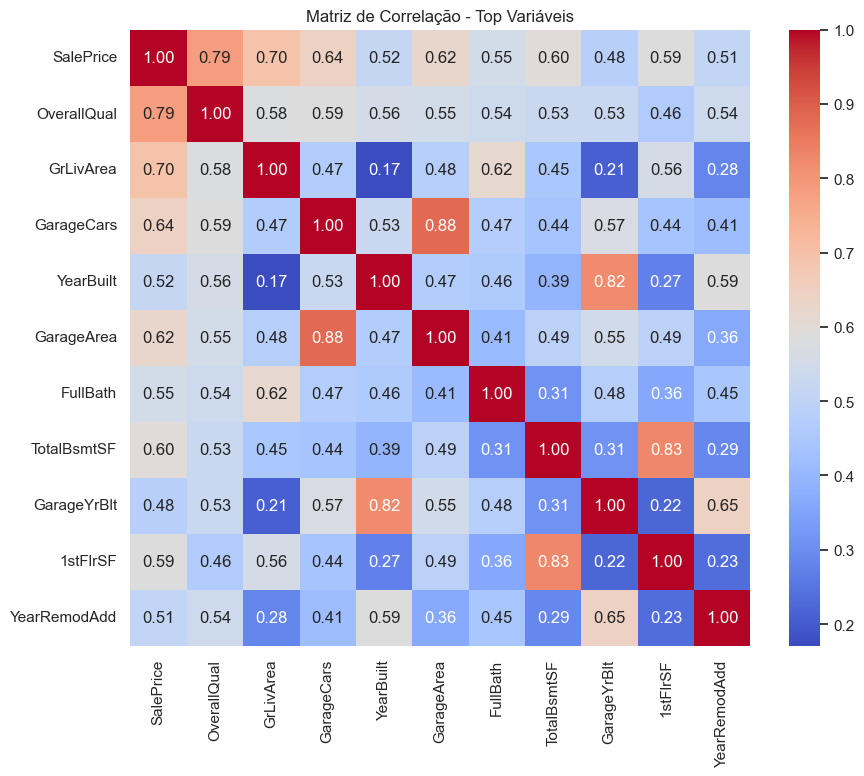

In [68]:
# Selecionar apenas variáveis numéricas
numericas = df_treino.select_dtypes(include=[np.number])

# Calcular a correlação de Spearman (captura relações não-lineares monótonas também)
correlacoes = numericas.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

# Mostrar as 10 variáveis com maior correlação positiva
print("Top 10 Variáveis mais correlacionadas com SalePrice:")
print(correlacoes.head(11)) # Inclui o próprio SalePrice

# Mapa de calor (Heatmap) das variáveis mais importantes
top_features = correlacoes.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_treino[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Top Variáveis')
plt.show()

## <h3>4. Estratégia de Limpeza de Dados (Valores Ausentes e Outliers) </h3>
Para garantir que o modelo consiga generalizar, precisamos mapear os dados nulos e definir nossa estratégia de inputação.

In [69]:
# Mapeamento de dados nulos
nulos = df_treino.isnull().sum()
nulos_percentual = (nulos / len(df_treino)) * 100
df_nulos = pd.DataFrame({'Total Nulos': nulos, 'Percentual (%)': nulos_percentual})
df_nulos = df_nulos[df_nulos['Total Nulos'] > 0].sort_values(by='Percentual (%)', ascending=False)

display(df_nulos)

,Total Nulos,Percentual (%)
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


## <h2>5 Visualização de Outras Variáveis Importantes</h2>

Como identificamos as variáveis numéricas mais correlacionadas com a variável alvo (`SalePrice`), é fundamental entender o comportamento das duas principais: `OverallQual` (Qualidade Geral) e `GrLivArea` (Área Habitável Acima do Solo). A análise visual nos ajuda a confirmar tendências e identificar potenciais *outliers* que podem distorcer o modelo.

C:\Users\kelis\AppData\Local\Temp\ipykernel_13296\1491837537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df_treino, ax=ax[0], palette='viridis')


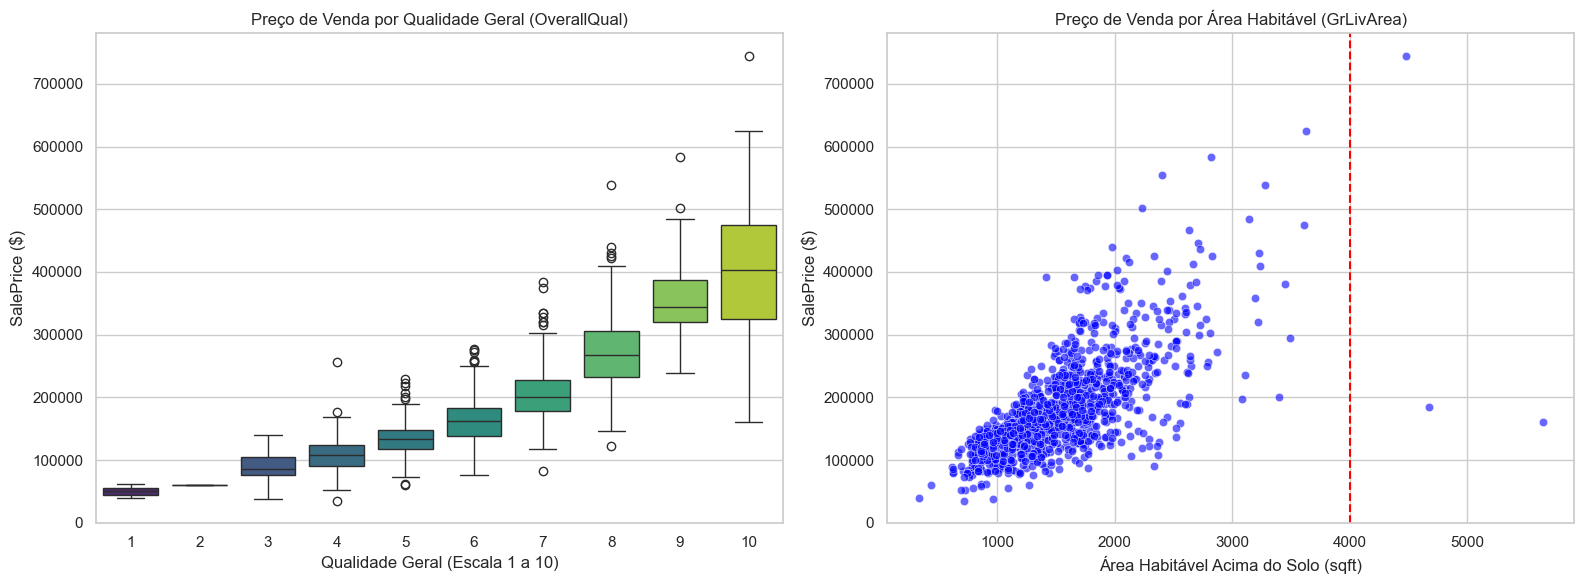

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=df_treino, ax=ax[0], palette='viridis')
ax[0].set_title('Preço de Venda por Qualidade Geral (OverallQual)')
ax[0].set_xlabel('Qualidade Geral (Escala 1 a 10)')
ax[0].set_ylabel('SalePrice ($)')

# Scatterplot de GrLivArea vs SalePrice
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_treino, ax=ax[1], alpha=0.6, color='blue')
ax[1].set_title('Preço de Venda por Área Habitável (GrLivArea)')
ax[1].set_xlabel('Área Habitável Acima do Solo (sqft)')
ax[1].set_ylabel('SalePrice ($)')
# Destacando potenciais outliers (imóveis gigantes muito baratos)
plt.axvline(x=4000, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Observação de Outliers: No gráfico de GrLivArea, é possível notar pontos no canto inferior direito. 
# São propriedades com área habitável enorme (> 4000 sqft), mas com preço de venda muito baixo. 

### 6. Justificativa de Imputação Baseada no Dicionário de Dados

Com a tabela acima e o dicionário de dados em mãos, a estratégia de tratamento será dividida em lógicas de negócio estruturadas:

1. **Atributos de Ausência Confirmada (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`):** 
   O dicionário afirma explicitamente que `NA` é "No Pool", "No Fence", etc. Substituiremos esses valores categóricos pela string `"None"`.
2. **Atributos de Garagem (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`):** 
   O dicionário indica `NA` como "No Garage". Preencheremos as categorias com `"None"`. Consequentemente, para as variáveis numéricas que descrevem a garagem (`GarageYrBlt`, `GarageArea`, `GarageCars`), onde não há garagem, o valor numérico correto é `0`.
3. **Atributos de Porão (`BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`):** 
   O dicionário indica `NA` como "No Basement". Preencheremos com `"None"`. Variáveis numéricas relacionadas (`BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath`) receberão `0`.
4. **Revestimento Externo de Alvenaria (`MasVnrType` e `MasVnrArea`):** 
   Se nulo, assumiremos que a casa não tem revestimento. Preenchimento com `"None"` na categoria e `0` na área.
5. **Dimensão Frontal do Lote (`LotFrontage`):** 
   Casos de ruas conectadas à propriedade tendem a ser consistentes dentro de um mesmo bairro. Imputaremos os valores ausentes com a **mediana da área do respectivo bairro (`Neighborhood`)**.
6. **Variáveis Categóricas Menores (`Electrical`):** 
   Ausência real de dado. Por se tratar de um sistema elétrico, imputaremos utilizando o valor mais frequente (moda).

In [71]:
# Criando uma cópia para preservar a integridade do dataset original
df_clean = df_treino.copy()

# 1. Atributos categóricos onde NA = "None"
cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("None")

# 2. Atributos numéricos vinculados a características inexistentes onde NA = 0
cols_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in cols_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# 3. Imputação Agrupada de LotFrontage baseada na mediana do Bairro (Neighborhood)
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 4. Imputação Simples da Moda para Electrical
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

# Validação Final de Nulos
nulos_restantes = df_clean.isnull().sum()
nulos_pendentes = nulos_restantes[nulos_restantes > 0]

print("Limpeza finalizada com sucesso!")
if len(nulos_pendentes) == 0:
    print("O dataset `df_clean` não possui mais valores nulos.")
    df_clean.to_csv('treino_clean.csv', index=False)
    print("Arquivo 'treino_clean.csv gerado")
else:
    print(f"Atenção, ainda há valores nulos nas seguintes colunas e csv não gerado:\n{nulos_pendentes}")

Limpeza finalizada com sucesso!
O dataset `df_clean` não possui mais valores nulos.
Arquivo 'treino_clean.csv gerado


# Acompanhamento 2: Pré-processamento da fase de Treinamento e Otimização de Modelos.

In [72]:
df_treino = pd.read_csv('treino_clean.csv')

# O alvo que queremos prever
y = df_treino['SalePrice'] 

# X deve conter TODAS as colunas, EXCETO o Id e o SalePrice
X = df_treino.drop(columns=['SalePrice', 'Id'], errors='ignore')

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
correlacoes = df_treino.corr(numeric_only=True) 

# Filtrando as top 10
top_10 = correlacoes['SalePrice'].sort_values(ascending=False).head(11)
print(top_10)

SalePrice       1.000000
OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
Name: SalePrice, dtype: float64


In [73]:
# Construção do Pipeline de pré-processamento

# Transforma para variaveis numéricas (preenche nulos com a mediana e padroniza)
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
        # handle_unknown='ignore' garante que categorias novas no teste não quebrem o código
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
    ]), cat_cols)
])

In [74]:
# Testando diferentes modelos para análise

# 1. Divisão dos dados em Treino e Validação (Evitando Data Leakage)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Dicionário com os modelos de teste!
modelos = {
    "Baseline (Linear Regression)": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, 
                            learning_rate=0.1, 
                            max_depth= 3, # Limita a profundidade da árvore (evita decorar)
                            subsample =0.8, # Usa apenas 80% das linhas por árvore
                            colsample_bytree = 0.8, # Usa apenas 80% das colunas por árvore
                            random_state=42)
}

# Validação cruzada de 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []
print("Avaliando os modelos (Validação Cruzada - 5 Folds)")
melhor_modelo_ = ""
menor_rmsle = float('inf')
melhor_pipeline = None

# 3. Treinamento e Extração de Métricas
for nome, modelo in modelos.items():
    # Transformação exigida para otimizar métricas baseadas em log (RMSLE)
    modelo_transformado = TransformedTargetRegressor(
        regressor=modelo, func=np.log1p, inverse_func=np.expm1
    )
    
    pipeline_completo = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('model', modelo_transformado)
    ])
    
    # Extração de métricas com Cross-Validation real
    cv_scores = cross_validate(
        pipeline_completo, X_train, y_train, cv=kf,
        scoring=('neg_mean_squared_log_error','neg_mean_squared_error' ,'r2', 'neg_mean_absolute_error'),
        n_jobs=-1
    )

    # Cálculo das médias das métricas através dos 5 testes
    rmsle_medio = np.mean(np.sqrt(-cv_scores['test_neg_mean_squared_log_error']))
    rmse_medio = np.mean(np.sqrt(-cv_scores['test_neg_mean_squared_error'])) 
    mae_medio = np.mean(-cv_scores['test_neg_mean_absolute_error'])
    r2_medio = np.mean(cv_scores['test_r2'])

    resultados.append({
        "Modelo": nome,
        "RMSLE (Média CV)": rmsle_medio,
        "RMSE Médio ($)": rmse_medio,
        "MAE Médio ($)": mae_medio,
        "R2 (Média CV)": r2_medio
    })
    
#4. Construção e Exibição do Ranking Oficial
df_resultados = pd.DataFrame(resultados).sort_values(by="RMSLE (Média CV)", ascending=True)

print("\n" + "="*60)
print("RANKING OFICIAL DOS MODELOS (Ordenado do Menor para o Maior Erro)")
print("="*60)

# Função para destacar dinamicamente o melhor valor de cada coluna
def destacar_melhores(coluna):
    if coluna.name in ['RMSLE (Média CV)', 'RMSE Médio ($)', 'MAE Médio ($)']:
        # Para erros, o melhor é o menor valor
        is_best = coluna == coluna.min()
    elif coluna.name == 'R2 (Média CV)':
        # Para o R², o melhor é o maior valor
        is_best = coluna == coluna.max()
    else:
        is_best = pd.Series(False, index=coluna.index)
    return ['background-color: lightgreen' if v else '' for v in is_best]

# Aplica a formatação na tabela
display(df_resultados.style.apply(destacar_melhores).format({
    "RMSLE (Média CV)": "{:.5f}",
    "RMSE Médio ($)": "$ {:,.2f}",
    "MAE Médio ($)": "$ {:,.2f}",
    "R2 (Média CV)": "{:.4f}"
}))

# 5. Treinamento do Modelo Vencedor para Submissão
melhor_modelo_nome = df_resultados.iloc[0]['Modelo']
print(f"\nO modelo selecionado para o pipeline final é: {melhor_modelo_nome}")

modelo_vencedor_instancia = modelos[melhor_modelo_nome]
pipeline_vencedor = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', TransformedTargetRegressor(regressor=modelo_vencedor_instancia, func=np.log1p, inverse_func=np.expm1))
])

# Treinamento final utilizando todos os dados de treino disponíveis
pipeline_vencedor.fit(X_train, y_train)

y_pred_val = pipeline_vencedor.predict(X_val)
y_pred_val = np.clip(y_pred_val, a_min=0, a_max=None) # Evita preços negativos

print("\n" + "="*55)
print(f"RESULTADOS MODELO VENCEDOR ({melhor_modelo_nome.upper()})")
print("="*55)
print(f"Métrica RMSLE: {root_mean_squared_log_error(y_val, y_pred_val):.5f}")
print(f"Métrica RMSE:  $ {np.sqrt(mean_squared_error(y_val, y_pred_val)):,.2f}")
print(f"Métrica MAE:   $ {mean_absolute_error(y_val, y_pred_val):,.2f}")
print(f"Métrica R²:    {r2_score(y_val, y_pred_val):.5f}")
print("-" * 55)
print(f"Total de amostras avaliadas: {len(X_val)}")
print("-" * 55 + "\n")

# Salvamento do modelo (.pkl) para consumo do pipeline.py
joblib.dump(pipeline_vencedor, 'modelo.pkl')
print(f"Modelo {melhor_modelo_nome} salvo com sucesso no arquivo 'modelo.pkl'!")

Avaliando os modelos (Validação Cruzada - 5 Folds)

RANKING OFICIAL DOS MODELOS (Ordenado do Menor para o Maior Erro)


,Modelo,RMSLE (Média CV),RMSE Médio ($),MAE Médio ($),R2 (Média CV)
3,XGBoost,0.12901,"$ 27,250.59","$ 16,354.81",0.8678
2,Random Forest,0.14673,"$ 30,468.27","$ 18,332.79",0.8365
1,Ridge Regression,0.15114,"$ 50,421.19","$ 18,591.27",0.2011
0,Baseline (Linear Regression),0.17713,"$ 51,949.08","$ 18,976.68",0.2791



O modelo selecionado para o pipeline final é: XGBoost

RESULTADOS MODELO VENCEDOR (XGBOOST)
Métrica RMSLE: 0.13872
Métrica RMSE:  $ 28,071.93
Métrica MAE:   $ 16,890.43
Métrica R²:    0.87809
-------------------------------------------------------
Total de amostras avaliadas: 234
-------------------------------------------------------

Modelo XGBoost salvo com sucesso no arquivo 'modelo.pkl'!


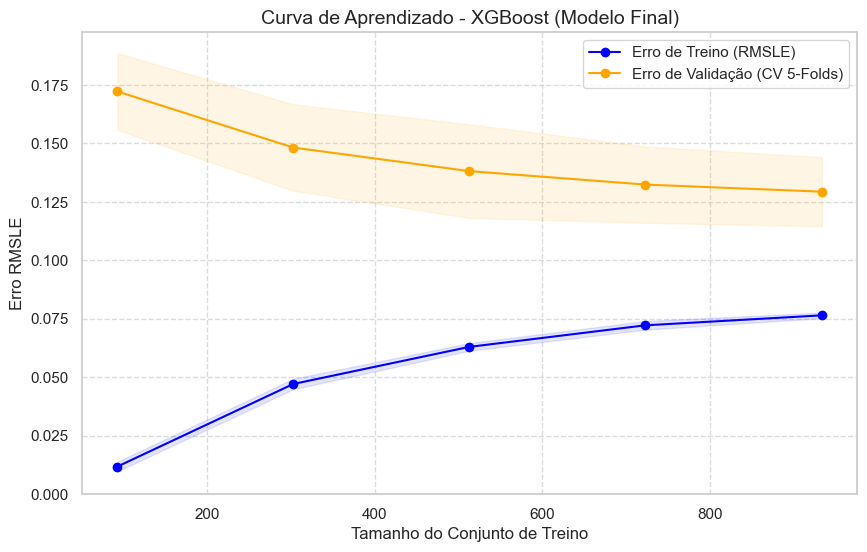

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curve(pipeline, X, y, title):
    # Utilizamos neg_mean_squared_log_error para que a validação cruzada monitore a métrica oficial
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X, y, cv=5, scoring='neg_mean_squared_log_error', 
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    # Convertendo os retornos negativos em RMSLE real
    train_scores_rmsle = np.sqrt(-train_scores)
    test_scores_rmsle = np.sqrt(-test_scores)
    
    train_mean = np.mean(train_scores_rmsle, axis=1)
    train_std = np.std(train_scores_rmsle, axis=1)
    test_mean = np.mean(test_scores_rmsle, axis=1)
    test_std = np.std(test_scores_rmsle, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Erro de Treino (RMSLE)")
    plt.plot(train_sizes, test_mean, 'o-', color="orange", label="Erro de Validação (CV 5-Folds)")
    
    # Sombreamento do desvio padrão para identificar a estabilidade do modelo
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    
    # Ajuste solicitado: Força o eixo Y a começar no zero
    plt.ylim(bottom=0)
    
    plt.title(f"Curva de Aprendizado - {title}", fontsize=14)
    plt.xlabel("Tamanho do Conjunto de Treino", fontsize=12)
    plt.ylabel("Erro RMSLE", fontsize=12)
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
# Gerando o diagnóstico visual para o modelo final salvo (Passamos o X e y originais)
plot_learning_curve(pipeline_vencedor, X, y, f"{melhor_modelo_nome} (Modelo Final)")